# CICF Week 11: Machine Learning Group Project

In this activity, we will transition from the Titanic dataset to a real-world scientific dataset: **NEON Mosquito Counts**.

Our goal is to use **Random Forests** and **XGBoost** to predict the number of mosquitoes found in a trap based on various features like the site, the time of year, and the species.

This is a group project. You will work together to:
1. Download the data from cloud storage.
2. Prepare the data for machine learning.
3. Train and evaluate a Random Forest model.
4. Train and evaluate an XGBoost model.
5. Compare results across different ecological sites.

## 1. Downloading Data from Cloud Storage

The NEON mosquito data is stored as a `.tar.gz` file on our cloud storage.
First, copy in credentials provided into a `.env` file.

     $ code .env

Now lets get the file, it is named `NEON_count-mosquitoes.tar.gz`.

In [3]:
import os
import boto3
from dotenv import load_dotenv
import pandas as pd

# Load credentials from .env file
load_dotenv()

ACCESS_KEY = os.getenv('DO_SPACES_KEY')
SECRET_KEY = os.getenv('DO_SPACES_SECRET')
ENDPOINT_URL = 'https://nyc3.digitaloceanspaces.com' # Or your region
BUCKET_NAME = os.getenv('DO_SPACES_BUCKET')
FILE_NAME = 'NEON_count-mosquitoes.tar.gz'

session = boto3.session.Session()
client = session.client('s3',
                        region_name='nyc3',
                        endpoint_url=ENDPOINT_URL,
                        aws_access_key_id=ACCESS_KEY,
                        aws_secret_access_key=SECRET_KEY)

try:
    client.download_file(BUCKET_NAME, FILE_NAME, FILE_NAME)
    print(f"Successfully downloaded {FILE_NAME}")
except Exception as e:
    print(f"Error downloading file: {e}")


Successfully downloaded NEON_count-mosquitoes.tar.gz


## 2. Data Exploration and Preparation

Untar the file and lets see what we have.

In [4]:
!tar xvfz NEON_count-mosquitoes.tar.gz

._NEON_count-mosquitoes
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.provenance'
NEON_count-mosquitoes/
NEON_count-mosquitoes/._NEON.D05.UNDE.DP1.10043.001.2022-03.expanded.20250129T000730Z.RELEASE-2025
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.provenance'
NEON_count-mosquitoes/NEON.D05.UNDE.DP1.10043.001.2022-03.expanded.20250129T000730Z.RELEASE-2025/
NEON_count-mosquitoes/._NEON.D05.UNDE.DP1.10043.001.2022-10.expanded.20250129T000730Z.RELEASE-2025
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.provenance'
NEON_count-mosquitoes/NEON.D05.UNDE.DP1.10043.001.2022-10.expanded.20250129T000730Z.RELEASE-2025/
NEON_count-mosquitoes/._NEON.D16.ABBY.DP1.1

The data consist of many files. Can you figure out how to consolidate all of them into a single Pandas dataframe? (hint: this is in the week 6 directory).
Save the big dataframe to a single `mosquito_data.csv` file.

In [9]:
df = pd.read_csv('mosquito_data.csv')
df.head()

,uid,namedLocation,domainID,siteID,plotID,setDate,collectDate,identifiedDate,subsampleID,subsampleCode,...,nativeStatusCode,identificationQualifier,sex,identificationReferences,sampleCondition,identificationRemarks,remarks,identifiedBy,laboratoryName,identificationHistoryID
0,e0a18bf8-a1ac-4b40-a023-b13842818ca7,UNDE_072.mosquitoPoint.mos,D05,UNDE,UNDE_072,2022-10-05T21:59Z,2022-10-06T13:01Z,2022-10-20,UNDE_072.20221006.0801.S.01,NaN,...,N,NaN,F,"Darsie Jr., R. F., and R. A. Ward. 2005. Ident...",No known compromise,NaN,NaN,D.S.Goldhammer,Kansas Biological Survey,NaN
1,3cb74d18-2f76-4528-aad6-01470f4ededc,UNDE_071.mosquitoPoint.mos,D05,UNDE,UNDE_071,2022-10-05T22:15Z,2022-10-06T13:23Z,2022-10-20,UNDE_071.20221006.0823.S.01,NaN,...,N,NaN,F,"Darsie Jr., R. F., and R. A. Ward. 2005. Ident...",No known compromise,NaN,NaN,D.S.Goldhammer,Kansas Biological Survey,NaN
2,a5d13d64-b0d6-4ffd-b16f-0894763d6425,UNDE_071.mosquitoPoint.mos,D05,UNDE,UNDE_071,2022-10-05T22:15Z,2022-10-06T13:23Z,2022-10-20,UNDE_071.20221006.0823.S.01,NaN,...,N,NaN,F,"Darsie Jr., R. F., and R. A. Ward. 2005. Ident...",No known compromise,NaN,NaN,D.S.Goldhammer,Kansas Biological Survey,NaN
3,5657b582-388d-4b75-b8e1-2085e11a0242,UNDE_066.mosquitoPoint.mos,D05,UNDE,UNDE_066,2022-10-05T22:23Z,2022-10-06T13:27Z,2022-10-20,UNDE_066.20221006.0827.S.01,NaN,...,N,NaN,F,"Darsie Jr., R. F., and R. A. Ward. 2005. Ident...",No known compromise,NaN,NaN,D.S.Goldhammer,Kansas Biological Survey,NaN
4,3f12c0af-55ea-4859-89b5-ae64db636d22,UNDE_066.mosquitoPoint.mos,D05,UNDE,UNDE_066,2022-10-05T22:23Z,2022-10-06T13:27Z,2022-10-20,UNDE_066.20221006.0827.S.01,NaN,...,N,NaN,F,"Darsie Jr., R. F., and R. A. Ward. 2005. Ident...",No known compromise,NaN,NaN,D.S.Goldhammer,Kansas Biological Survey,NaN


We need to clean the data and create features that the machine learning model can understand.
We will drop rows where `individualCount` is missing. (These rows do help assert the _absence_ of a species, but we don't need them to predict counts). We will also extract more useful date information and identify which variables are _categories_ and not numeric measurments or counts.

In [23]:
import numpy as np

def prepare_mosquito_data(df):
    # Drop rows with missing counts
    df = df.dropna(subset=['individualCount'])
    
    # Convert date to datetime
    df['collectDate'] = pd.to_datetime(df['collectDate'])
    
    # Extract time features
    df['year'] = df['collectDate'].dt.year
    df['day_of_year'] = df['collectDate'].dt.dayofyear
    
    # Keep only relevant columns for prediction
    cols = ['siteID', 'plotID', 'year', 'day_of_year', 'taxonID', 'individualCount', 'sex']
    df = df[cols].copy()
    
    # Convert categorical to codes
    df['siteID'] = pd.Categorical(df.siteID).codes
    df['plotID'] = pd.Categorical(df.plotID).codes
    df['taxonID'] = pd.Categorical(df.taxonID).codes
    df['sex'] = pd.Categorical(df.sex).codes
    
    return df

df_clean = prepare_mosquito_data(df)
df_clean.head()

,siteID,plotID,year,day_of_year,taxonID,individualCount,sex
0,1,15,2022,279,1,1.0,0
1,1,14,2022,279,26,2.0,0
2,1,14,2022,279,23,1.0,0
3,1,10,2022,279,23,1.0,0
4,1,10,2022,279,26,4.0,0


In [12]:
cats=['siteID','plotID', 'taxonID', 'sex']
conts=['day_of_year', 'year']
dep='individualCount'

### Visualizing the target
Mosquito counts often vary wildly. Let's look at the distribution.

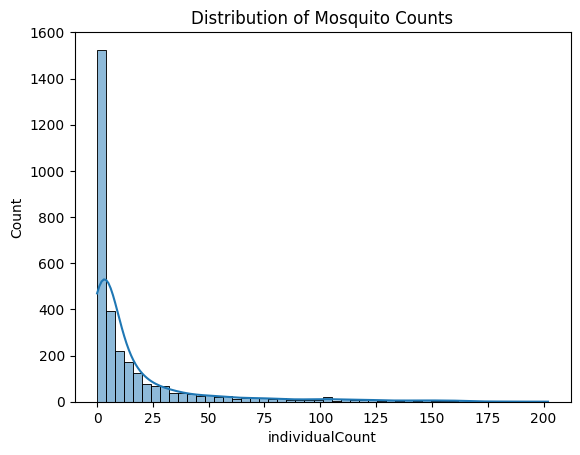

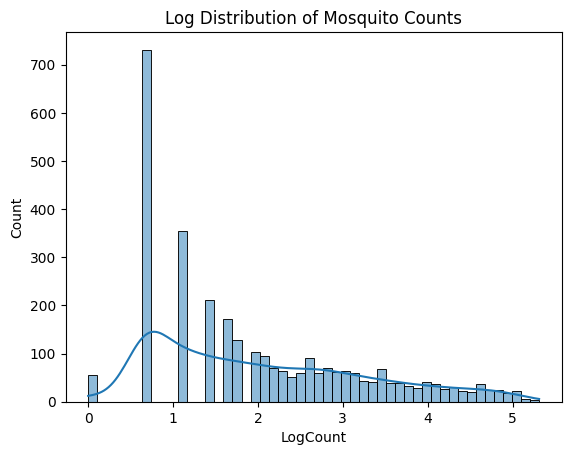

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_clean['individualCount'], bins=50, kde=True)
plt.title('Distribution of Mosquito Counts')
plt.show()

# Often in count data, a log transform helps
df_clean['LogCount'] = np.log1p(df_clean['individualCount'])
sns.histplot(df_clean['LogCount'], bins=50, kde=True)
plt.title('Log Distribution of Mosquito Counts')
plt.show()

## 3. Random Forest Modeling

Split the data into training and validation sets, then train a `RandomForestRegressor`.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = df_clean.drop(['individualCount', 'LogCount'], axis=1)
Y = df_clean['LogCount']

trn_xs, val_xs, trn_ys, val_ys = train_test_split(X, Y, test_size=0.2, random_state=42)


array([[<Axes: title={'center': 'siteID'}>,
        <Axes: title={'center': 'plotID'}>],
       [<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'day_of_year'}>],
       [<Axes: title={'center': 'taxonID'}>,
        <Axes: title={'center': 'sex'}>]], dtype=object)

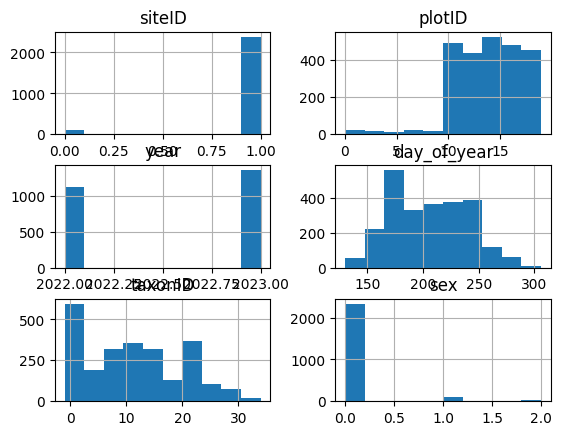

In [26]:
trn_xs.hist()

In [21]:
trn_xs.head()

,siteID,plotID,year,day_of_year,taxonID,sex
1175,UNDE,UNDE_073,2023,251,AEDFIT,F
169,UNDE,UNDE_068,2022,153,AEDPUN,F
2592,UNDE,UNDE_075,2023,209,CULMOR,F
2799,UNDE,UNDE_066,2022,195,AEDCAN3,F
1934,UNDE,UNDE_068,2023,222,ANOPUN,F


In [28]:
rf = RandomForestRegressor(n_estimators=100, min_samples_leaf=5, random_state=42)
rf.fit(trn_xs, trn_ys)

preds = rf.predict(val_xs)
print(f"Validation R2 Score: {r2_score(val_ys, preds):.4f}")
print(f"Validation MAE (log scale): {mean_absolute_error(val_ys, preds):.4f}")

Validation R2 Score: 0.7538
Validation MAE (log scale): 0.4615


In [41]:
np.exp([val_ys[0], preds[0]])

array([2.        , 2.40616679])

### Which features matter most?
One of the best parts of Random Forests is that they tell us which features were most useful for the prediction.

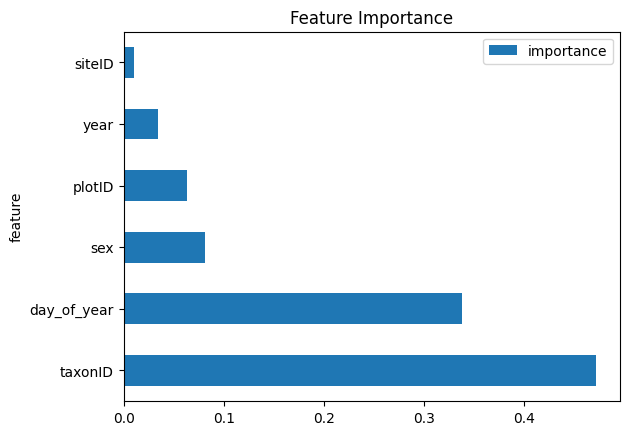

In [42]:
import pandas as pd
fi = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
fi.plot.barh(x='feature', y='importance')
plt.title('Feature Importance (Random Forest)')
plt.show()

## 4. XGBoost: Gradient Boosting

While Random Forests build many independent trees and average them, **XGBoost** (eXtreme Gradient Boosting) builds trees sequentially, where each new tree tries to correct the errors made by the previous ones.

Let's see how it performs on our dataset.

In [ ]:
from xgboost import XGBRegressor

# Initialize and train the XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict and evaluate
xgb_preds = xgb_model.predict(X_val)
print(f"Validation R2 Score (XGBoost): {r2_score(y_val, xgb_preds):.4f}")
print(f"Validation MAE (XGBoost, log scale): {mean_absolute_error(y_val, xgb_preds):.4f}")

### Comparison

How does XGBoost compare to Random Forest in terms of accuracy and feature importance?

In [ ]:
xgb_fi = pd.DataFrame({'feature': X.columns, 'importance': xgb_model.feature_importances_}).sort_values('importance', ascending=False)
xgb_fi.plot.barh(x='feature', y='importance', color='orange')
plt.title('Feature Importance (XGBoost)')
plt.show()